
# Kappa (Cohen) y Validación Cruzada en Clasificación

Este notebook explica:

- Qué es **Cohen's kappa (κ)** y por qué puede ser más informativo que la *accuracy* en algunos escenarios.
- Qué es la **validación cruzada (cross-validation)** en clasificación y cómo aplicarla correctamente.
- Cómo evaluar modelos usando *accuracy* y **κ** sobre un dataset libre incluido en `scikit-learn`.

> **Dataset usado (libre):** *Breast Cancer Wisconsin (Diagnostic)*, incluido en `sklearn.datasets`.



## 1) Preparación

Vamos a cargar librerías y el dataset. Trabajaremos con un modelo base (Regresión Logística) y usaremos pipelines para mantener un flujo correcto (por ejemplo, escalado dentro del CV).


In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    cohen_kappa_score,
    classification_report,
    make_scorer,
)
import matplotlib.pyplot as plt

# Cargar dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")  # 0=maligno, 1=benigno

X.shape, y.value_counts()


((569, 30),
 target
 1    357
 0    212
 Name: count, dtype: int64)

## 2) ¿Qué es Cohen's kappa (κ)?

**Cohen's kappa (κ)** es una medida del grado de acuerdo entre dos evaluadores.
En el contexto de clasificación supervisada, estos evaluadores son:

- El modelo
- La etiqueta real (ground truth)

A diferencia de la *accuracy*, κ ajusta el acuerdo observado descontando el acuerdo que podría ocurrir por azar.

---

### Definición

La estadística κ se define como:

$$
\kappa = \frac{p_o - p_e}{1 - p_e}
$$

donde:

- $p_o$ es el acuerdo observado.
- $p_e$ es el acuerdo esperado por azar.

---

### Acuerdo observado ($p_o$)

El acuerdo observado es la proporción de predicciones correctas:

$$
p_o = \frac{\text{número de aciertos}}{N}
$$

En clasificación estándar, esto coincide con la **accuracy**.

---

### Acuerdo esperado por azar ($p_e$)

El acuerdo esperado se calcula usando las distribuciones marginales de la matriz de confusión.

Para clasificación binaria, si la matriz de confusión es:

$$
\begin{array}{c|cc}
 & \text{Pred 0} & \text{Pred 1} \\
\hline
\text{Real 0} & a & b \\
\text{Real 1} & c & d \\
\end{array}
$$

y $N = a + b + c + d$, entonces:

$$
p_e =
\left(
\frac{a+b}{N} \cdot \frac{a+c}{N}
\right)
+
\left(
\frac{c+d}{N} \cdot \frac{b+d}{N}
\right)
$$

El primer término corresponde a la probabilidad de coincidencia en la clase 0 por azar,
y el segundo término a la probabilidad de coincidencia en la clase 1 por azar.

---

### Interpretación

- $\kappa = 1$: acuerdo perfecto.
- $\kappa = 0$: el acuerdo es equivalente al azar.
- $\kappa < 0$: el acuerdo es peor que el azar.

En la práctica, valores mayores a 0.6 suelen considerarse indicativos de buen acuerdo,
aunque esta interpretación depende del contexto del problema.

---

### Observaciones

- Si el conjunto de datos está balanceado, accuracy y κ suelen ser similares.
- En presencia de desbalance de clases, κ suele ser más informativo.
- κ puede utilizarse también en problemas multi-clase.



### 2.1) Ejemplo rápido en un hold-out

Primero haremos un split entrenamiento/prueba para ver métricas básicas, matriz de confusión, accuracy y κ.


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, n_jobs=None, solver="lbfgs"))
])

pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)

acc = accuracy_score(y_test, pred)
kappa = cohen_kappa_score(y_test, pred)

acc, kappa


(0.986013986013986, 0.970020964360587)


### 2.2) Matriz de confusión y reporte

La matriz de confusión ayuda a ver **qué tipo de errores** comete el modelo.


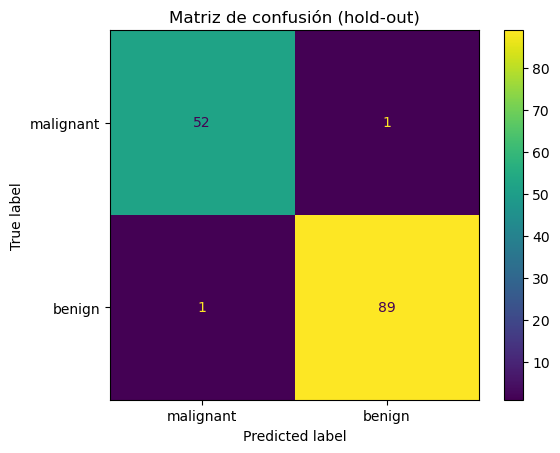

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



In [3]:
cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(values_format="d")
plt.title("Matriz de confusión (hold-out)")
plt.show()

print(classification_report(y_test, pred, target_names=data.target_names))



## 3) ¿Por qué κ puede ser útil? (mini-ejemplo con desbalance)

Imagina un dataset muy desbalanceado (p. ej. 95% clase A, 5% clase B).  
Un clasificador "tonto" que siempre predice A tendría **accuracy ≈ 95%**, pero **no está aprendiendo nada útil**.

κ tiende a penalizar este comportamiento porque el acuerdo esperado por azar (\(p_e\)) sería alto.


In [4]:
# Simulación simple: 1000 ejemplos, 95% clase 0 y 5% clase 1
rng = np.random.default_rng(0)
y_true = np.array([0]*950 + [1]*50)

# Clasificador trivial: siempre predice 0
y_pred_trivial = np.zeros_like(y_true)

acc_trivial = accuracy_score(y_true, y_pred_trivial)
kappa_trivial = cohen_kappa_score(y_true, y_pred_trivial)

acc_trivial, kappa_trivial


(0.95, 0.0)


**Resultado esperado:** accuracy alta (≈0.95), pero κ cercano a 0 (o exactamente 0), indicando que el "acuerdo" no es mejor que el azar dada la distribución.

Esto ilustra por qué en problemas con desbalance o con costos distintos de error, no conviene mirar solo accuracy.



## 4) ¿Qué es Validación Cruzada (Cross-Validation) en clasificación?

La **validación cruzada** estima el rendimiento del modelo **de forma más robusta** que un solo split *train/test*.

**K-fold CV**:

1. Se divide el conjunto de datos en *K* particiones (folds).
2. Se entrena el modelo *K* veces:
   - cada vez usa *K-1* folds para entrenar
   - y 1 fold distinto para validar
3. Se promedian las métricas.

En **clasificación**, es común usar **StratifiedKFold**, que intenta mantener la **proporción de clases** en cada fold.

> Importante: cualquier preprocesamiento (p. ej., escalado) debe estar **dentro** del CV, por eso usamos `Pipeline`.


In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "kappa": make_scorer(cohen_kappa_score)
}

results = cross_validate(
    pipe, X, y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

pd.DataFrame(results).agg(["mean", "std"])


,fit_time,score_time,test_accuracy,test_kappa
mean,0.005663,0.001237,0.973669,0.942867
std,0.002436,0.001132,0.018590,0.040890



### 4.1) Distribución de métricas por fold

Ver la variabilidad por fold es útil: un promedio alto con mucha varianza puede indicar sensibilidad a la partición.


In [6]:
df = pd.DataFrame({
    "accuracy": results["test_accuracy"],
    "kappa": results["test_kappa"],
})

df


,accuracy,kappa
0,0.973684,0.944245
1,0.947368,0.884810
2,0.964912,0.923077
3,0.991228,0.981244
4,0.991150,0.980960


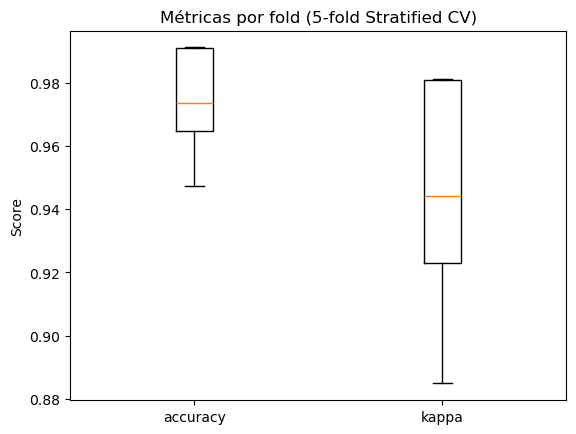

Accuracy media ± std: 0.9736686849868033 ± 0.018589799576866343
Kappa media ± std: 0.9428672097281853 ± 0.04089035694424213


In [7]:
plt.figure()
plt.boxplot([df["accuracy"], df["kappa"]], labels=["accuracy", "kappa"])
plt.title("Métricas por fold (5-fold Stratified CV)")
plt.ylabel("Score")
plt.show()

print("Accuracy media ± std:", df["accuracy"].mean(), "±", df["accuracy"].std())
print("Kappa media ± std:", df["kappa"].mean(), "±", df["kappa"].std())



## 5) Buenas prácticas y notas

- **Usa StratifiedKFold** en clasificación (especialmente con desbalance).
- Pon el preprocesamiento dentro de un **Pipeline** (evita *data leakage*).
- Reporta varias métricas (accuracy, κ, F1, ROC-AUC, etc.) según el problema.
- κ es especialmente útil cuando:
  - hay **desbalance**,
  - quieres ajustar por **acuerdo esperado por azar**,
  - comparas modelos que podrían “acertar” mucho solo por la distribución de clases.

Si quieres, puedes reemplazar la Regresión Logística por SVM, Random Forest, XGBoost, etc., y comparar métricas bajo el mismo esquema de CV.
